# Loading Data and Packages

In [1]:
import pandas as pd
import numpy as np 
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
import re 
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
df = pd.read_csv(r"C:\Users\AlexaJohnston\Springboard\Enron_Investigation_Capstone\Enron_Investigation_Notebooks\clean_emails.csv")

## Cleaning Text

In [2]:
def clean_text(text): 
    text = str(text).lower() 
    text = re.sub(r'\n', ' ', text) 
    text = re.sub(r'\s+', ' ', text) 
    text = text = re.sub(r'(.)\1{10,}', '', text)
    return text.strip()
df['body_clean'] = df['body_clean'].apply(clean_text)
df = df.rename(columns={'body_clean':'body'})

# Tokenization

In [3]:
nltk.download('punkt_tab')
df['tokens'] = df['body'].apply(word_tokenize)

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\AlexaJohnston\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [4]:
df['word_count'] = df['tokens'].apply(len)

In [5]:
df['word_count']

0         31
1       1489
2         84
3         12
4        103
        ... 
2471      67
2472     108
2473     278
2474       1
2475     313
Name: word_count, Length: 2476, dtype: int64

In [6]:
avg_word_count = df['word_count'].mean()
avg_word_count

np.float64(304.78352180937)

# Sentence Segmentation

In [7]:
df['sentences'] = df['body'].apply(sent_tokenize)
df['sentence_count'] = df['sentences'].apply(len)

In [8]:
df['sentence_count']

0        3
1       38
2        3
3        1
4        4
        ..
2471     6
2472     3
2473     6
2474     1
2475    10
Name: sentence_count, Length: 2476, dtype: int64

In [9]:
avg_sentence_lengths = []
for email_sents in df['sentences']:
    if len(email_sents) == 0:
        avg_len = 0
    else:
        sent_word_counts = [len(sent.split()) for sent in email_sents]
        avg_len = sum(sent_word_counts) / len(sent_word_counts)
    avg_sentence_lengths.append(avg_len)
df['avg_sentence_len'] = avg_sentence_lengths

# Feature Matrix

In [10]:
feature_matrix = pd.DataFrame()

In [11]:
feature_matrix['email_index'] = df.index
feature_matrix['custodian'] = df['custodian']
feature_matrix['folder_source'] = df['folder_source']

In [12]:
feature_matrix['word_count'] = df['word_count']
feature_matrix['sentence_count'] = df['sentence_count']

In [13]:
feature_matrix['avg_sentence_len'] = df['avg_sentence_len']

# LIWC

In [14]:
def remove_punctuation(string):
    text = ' '.join(string)
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    return text.split()
df['tokens_liwc'] = df['tokens'].apply(remove_punctuation)

In [15]:
categories = {
    'personal_pronouns':['i', 'me', 'my', 'myself', 'we', 'us', 'our'], 
    'negations':['not', "none", "don't", "never", "no", "cannot", "can't", "nothing", "nobody"], 
    'uncertainty':['maybe', 'might', 'could', 'possibly', 'unsure', 'perhaps'], 
    'emotive_language':['happy', 'angry', 'worried', 'fear', 'excited', 'concerned'],
    'cognitive_process': ['think','know','consider','believe','reason','assume'],
    'finance_words': ['account','invoice','profit','loss','revenue','budget','audit'],
    'authority_words': ['must','should','command','order','direct','require','authorize'],
    'fraud_words':['hide', 'cover up', 'know', 'aware', 'misrepresent', 'rush', 'urgent', 'secret', 'illegal', 'unethical', 'off the record', "let's take this offline", 'tyop', 'ldl', 'expected to announce', 'leak', 'do not share', 'breach']
}

In [16]:
for cat in categories: 
    feature_matrix[cat + '_count'] = 0

In [17]:
for i, email in enumerate(df['body']): 
    word = df['tokens_liwc']
    for cat, words in categories.items():
        count = 0
        for word in word:
            if word in words:
                count += 1
        feature_matrix.at[i, cat + '_count'] = count

In [18]:
feature_matrix.head()

,email_index,custodian,folder_source,word_count,sentence_count,avg_sentence_len,personal_pronouns_count,negations_count,uncertainty_count,emotive_language_count,cognitive_process_count,finance_words_count,authority_words_count,fraud_words_count
0,0,lay-k,deleted_items,31,3,7.000000,0,1,0,0,0,0,0,0
1,1,lay-k,deleted_items,1489,38,30.894737,0,1,0,0,0,0,0,0
2,2,lay-k,discussion_threads,84,3,24.000000,0,1,0,0,0,0,0,0
3,3,lay-k,discussion_threads,12,1,11.000000,0,1,0,0,0,0,0,0
4,4,lay-k,discussion_threads,103,4,22.750000,0,1,0,0,0,0,0,0


# Feature Scaling

In [19]:
num = feature_matrix.select_dtypes(include='number').columns
X_num = feature_matrix[num]
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num)  

In [20]:
X_cat = pd.get_dummies(feature_matrix[['custodian', 'folder_source']], drop_first=True)

In [21]:
X_final = np.hstack([X_num_scaled, X_cat.values])

# PCA

In [22]:
pca = PCA(n_components=0.9)
pca_ft = pca.fit_transform(X_num_scaled)

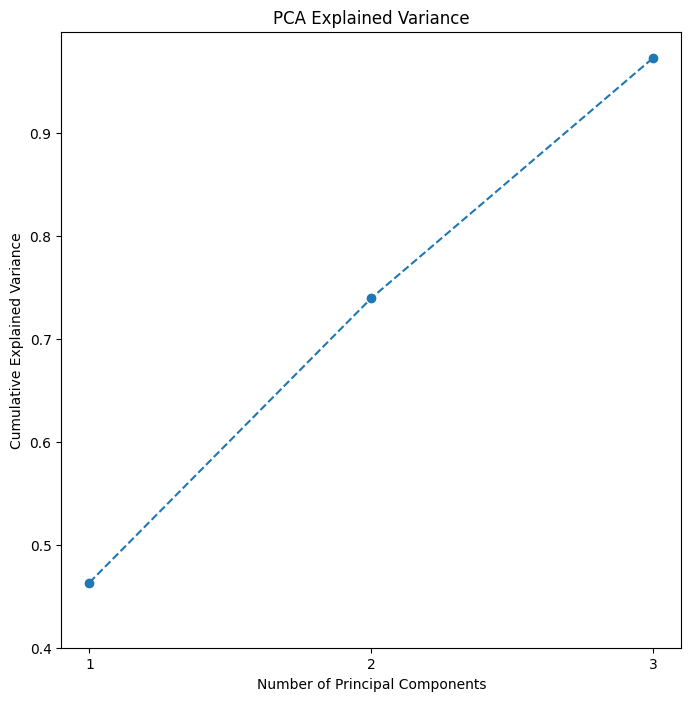

In [23]:
plt.figure(figsize=(8,8))
plt.plot(range(1, len(pca.explained_variance_ratio_)+1),
         np.cumsum(pca.explained_variance_ratio_),
         marker='o', linestyle='--')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.yticks([0.4, 0.5, 0.6, 0.7, 0.8, 0.9])
plt.xticks([1, 2, 3])
plt.show()

In [24]:
feature_matrix.columns

Index(['email_index', 'custodian', 'folder_source', 'word_count',
       'sentence_count', 'avg_sentence_len', 'personal_pronouns_count',
       'negations_count', 'uncertainty_count', 'emotive_language_count',
       'cognitive_process_count', 'finance_words_count',
       'authority_words_count', 'fraud_words_count'],
      dtype='object')

In [25]:
print("PC1:", pca.components_[0])
print("PC2:", pca.components_[1])
print("PC3:", pca.components_[2])

PC1: [ 0.01702126  0.70847019  0.70508045  0.02533406 -0.         -0.
 -0.         -0.         -0.         -0.         -0.         -0.        ]
PC2: [-0.62738033  0.10957403 -0.12230586  0.76120216 -0.         -0.
 -0.         -0.         -0.         -0.         -0.         -0.        ]
PC3: [ 0.77837922  0.05929063 -0.10053031  0.61685012  0.          0.
  0.          0.          0.          0.          0.          0.        ]


In [26]:
df_pca = pd.DataFrame(pca_ft)
df_final = pd.concat([df_pca, X_cat.reset_index(drop=True)], axis=1)
df_final.head()

,0,1,2,custodian_skilling-j,folder_source__sent_mail,folder_source_deleted_items,folder_source_discussion_threads,folder_source_notes_inbox,folder_source_sent,folder_source_sent_items
0,-0.841000,0.359926,-1.916882,False,False,True,False,False,False,False
1,3.359382,1.192586,-1.343196,False,False,True,False,False,False,False
2,-0.735939,0.923314,-1.460341,False,False,False,True,False,False,False
3,-0.970005,0.500061,-1.796421,False,False,False,True,False,False,False
4,-0.655012,0.876918,-1.495734,False,False,False,True,False,False,False


# Saving

In [27]:
feature_matrix.to_csv("email_features.csv", index=False)

In [28]:
df_final['email_index'] = df.index
df_final.to_csv("email_pca_components.csv", index=False)

# References

1. DePaulo et al. (2003) — Cues to Deception
2. Newman et al. (2003) — LIWC & Deception
3. Abbasi & Chen (2008) — Enron deception analysis
4. Gao et al. (2018) — Text analytics for insider threat detection
5. Pennebaker et al. (2001) — LIWC Manual & Validation
6. Schwartz et al. (2013) — Personality, LIWC, deception, and W matrix